# Supervised Machine Learning with scikit-learn: A Comparative Study Across Three Datasets

**Author:** Kulnoor Bajwa  
**Course:** Csci 164  

##  Project Overview

This project develops and evaluates multiple supervised learning models across three classical datasets using scikit-learn. Two classification problems and one regression problem are studied. For each dataset, 3 to 4 algorithms are trained and tuned with `GridSearchCV`, and compared with appropriate metrics. The Results are compared against published prior work.

## Datasets

| # | Dataset | Task | Samples | Features | Prior Work |
|---|---------|------|---------|----------|------------|
| 1 | Breast Cancer Wisconsin (Diagnostic) | Binary classification | 569 | 30 | Street, Wolberg & Mangasarian (1993) |
| 2 | Optical Recognition of Handwritten Digits | Multi-class classification (10 classes) | 1,797 | 64 | Alpaydin & Kaynak (1998) |
| 3 | Diabetes Progression | Regression | 442 | 10 | Efron, Hastie, Johnstone & Tibshirani (2004) |

All three datasets come from the UCI Machine Learning Repository and are accessible through `sklearn.datasets`. They were chosen because each supports a clean and different ML task (binary classification, multi-class classification, regression), each has a well-known published baseline to compare against, and together they span low/medium dimensionality and small/medium sample sizes, and enough variety to show where each algorithm family shines or struggles.

## Algorithms evaluated

- **Classification:** Logistic Regression, k-Nearest Neighbors, Random Forest, Multi-Layer Perceptron (MLP)  
- **Regression:** Linear Regression, k-Nearest Neighbors Regressor, Decision Tree Regressor, MLP Regressor


## 1. Setup and Imports

In [1]:
# core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn datasets
from sklearn.datasets import load_breast_cancer, load_digits, load_diabetes

# preprocessing and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# classifiers
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor

# metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    ConfusionMatrixDisplay
)

# suppress the convergence warnings that come up when we grid-search over small C/alpha values
import warnings
warnings.filterwarnings("ignore")

# global seed so every split/fit is reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# cleaner default plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100

print("Setup complete.")

Setup complete.


---
## 2. Dataset 1: Breast Cancer Wisconsin (Diagnostic)

### 2.1 Why this dataset?

The Wisconsin Diagnostic Breast Cancer (WDBC) dataset is one of the most cited benchmarks in medical ML. Each row is a digitized image of a fine needle aspirate of a breast mass, and the task is to classify the tumor as **malignant** or **benign** from 30 numerical features (mean, standard error, and "worst" values for ten cell-nucleus measurements like radius, texture, perimeter, area, smoothness, etc.).

I chose it because it's a clean binary classification problem with a strong published baseline, all features are numeric (no encoding needed), and it's small enough that full grid search is tractable without a GPU.

### 2.2 Prior work

Street, Wolberg & Mangasarian (1993) introduced the dataset alongside a linear-programming diagnostic classifier (MSM-T) and reported about **97% cross-validated classification accuracy** using three selected features. Later work using SVMs and ensemble methods has pushed the ceiling above 98%. I'll compare my models against that ~97 baseline.


In [2]:
# load the data and build a DataFrame for nicer inspection
bc = load_breast_cancer()
bc_df = pd.DataFrame(bc.data, columns=bc.feature_names)
bc_df["target"] = bc.target  # 0 = malignant, 1 = benign

print("Shape:", bc_df.shape)
print("\nTarget classes:", dict(zip(bc.target_names, np.bincount(bc.target))))
print("\nClass balance: {:.1%} benign, {:.1%} malignant".format(
    (bc.target == 1).mean(), (bc.target == 0).mean()))
bc_df.head()

Shape: (569, 31)

Target classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

Class balance: 62.7% benign, 37.3% malignant


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# basic descriptive stats for the first handful of features
bc_df.iloc[:, :6].describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10
std,3.52,4.30,24.30,351.91,0.01,0.05
min,6.98,9.71,43.79,143.50,0.05,0.02
25%,11.70,16.17,75.17,420.30,0.09,0.06
50%,13.37,18.84,86.24,551.10,0.10,0.09
75%,15.78,21.80,104.10,782.70,0.11,0.13
max,28.11,39.28,188.50,2501.00,0.16,0.35


In [4]:
# check for missing values
print("Total missing values:", bc_df.isnull().sum().sum())
print("Feature dtypes:", bc_df.dtypes.unique())

Total missing values: 0
Feature dtypes: [dtype('float64') dtype('int64')]


### 2.3 Exploratory plots

A quick look at class separability for a couple of top features, and a correlation heatmap to see how strongly the features are related (this affects which algorithms will do well).

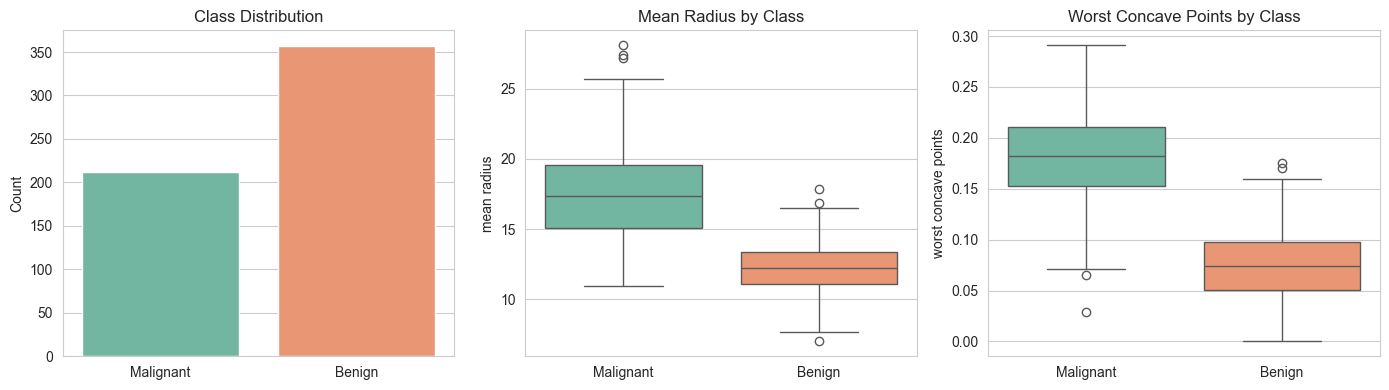

In [5]:
# class distribution + two informative features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) class counts
sns.countplot(x=bc_df["target"].map({0: "Malignant", 1: "Benign"}), ax=axes[0],
              hue=bc_df["target"].map({0: "Malignant", 1: "Benign"}), palette="Set2", legend=False)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

# (b) mean radius by class
sns.boxplot(x=bc_df["target"].map({0: "Malignant", 1: "Benign"}),
            y=bc_df["mean radius"], ax=axes[1],
            hue=bc_df["target"].map({0: "Malignant", 1: "Benign"}),
            palette="Set2", legend=False)
axes[1].set_title("Mean Radius by Class")
axes[1].set_xlabel("")

# (c) worst concave points by class — historically one of the most predictive features
sns.boxplot(x=bc_df["target"].map({0: "Malignant", 1: "Benign"}),
            y=bc_df["worst concave points"], ax=axes[2],
            hue=bc_df["target"].map({0: "Malignant", 1: "Benign"}),
            palette="Set2", legend=False)
axes[2].set_title("Worst Concave Points by Class")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

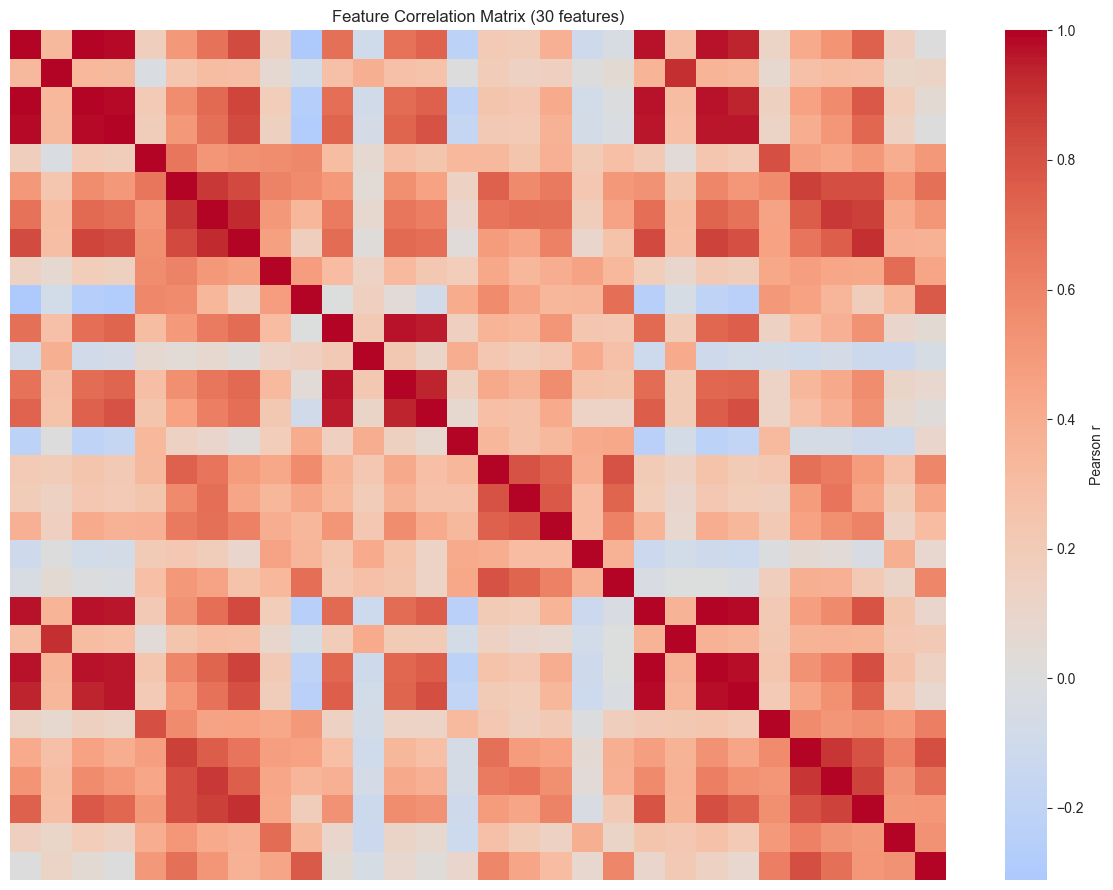

In [6]:
# correlation heatmap — a lot of these features are redundant (radius, perimeter, area all measure size)
plt.figure(figsize=(12, 9))
sns.heatmap(bc_df.iloc[:, :30].corr(), cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False, cbar_kws={"label": "Pearson r"})
plt.title("Feature Correlation Matrix (30 features)")
plt.tight_layout()
plt.show()

**Observations.** The classes separate clearly on features like `mean radius` and `worst concave points`, which is a good sign for linear models. The heatmap shows strong block-correlations (radius/perimeter/area are near-duplicates, as expected from their geometric definitions), which makes regularization (L2 in logistic regression) more important than it would be on independent features.

### 2.4 Preprocessing

No missing values, no categorical features, so the only preprocessing needed is feature scaling. Distance-based (KNN) and gradient-based (MLP, regularized logistic regression) methods need it; tree ensembles don't, but scaling doesn't hurt them either. I wrap scaling in a `Pipeline` so it happens **inside each CV fold**, which prevents test-fold information from leaking into the training statistics.

In [7]:
X_bc, y_bc = bc.data, bc.target
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.20, stratify=y_bc, random_state=RANDOM_STATE
)
print(f"Train: {X_train_bc.shape}, Test: {X_test_bc.shape}")
print(f"Train class balance: {np.bincount(y_train_bc)}, "
      f"Test class balance: {np.bincount(y_test_bc)}")

Train: (455, 30), Test: (114, 30)
Train class balance: [170 285], Test class balance: [42 72]


### 2.5 Model development and hyperparameter tuning

Four models are tuned with 5-fold stratified CV on the training set, scoring on accuracy. Each model is wrapped in a Pipeline with `StandardScaler` so scaling is refit per fold.

In [8]:
# dict to accumulate all results for the comparison table later
bc_results = {}

cv_bc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ---------- Logistic Regression ----------
# L2-regularized; C is the inverse regularization strength
lr_pipe = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])
lr_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
           "clf__penalty": ["l2"]}
lr_gs = GridSearchCV(lr_pipe, lr_grid, cv=cv_bc, scoring="accuracy", n_jobs=-1)
lr_gs.fit(X_train_bc, y_train_bc)
bc_results["LogisticRegression"] = lr_gs
print(f"Logistic Regression best params: {lr_gs.best_params_}")
print(f"  CV accuracy: {lr_gs.best_score_:.4f}")

Logistic Regression best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
  CV accuracy: 0.9824


In [9]:
# ---------- K-Nearest Neighbors ----------
knn_pipe = Pipeline([("scaler", StandardScaler()),
                     ("clf", KNeighborsClassifier())])
knn_grid = {"clf__n_neighbors": [3, 5, 7, 11, 15, 21],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2]}  # Manhattan vs Euclidean
knn_gs = GridSearchCV(knn_pipe, knn_grid, cv=cv_bc, scoring="accuracy", n_jobs=-1)
knn_gs.fit(X_train_bc, y_train_bc)
bc_results["KNN"] = knn_gs
print(f"KNN best params: {knn_gs.best_params_}")
print(f"  CV accuracy: {knn_gs.best_score_:.4f}")

KNN best params: {'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'uniform'}
  CV accuracy: 0.9714


In [10]:
# ---------- Random Forest ----------
# scaling not needed for trees, but keeping the pipeline uniform
rf_pipe = Pipeline([("scaler", StandardScaler()),
                    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {"clf__n_estimators": [100, 300],
           "clf__max_depth": [None, 10],
           "clf__min_samples_split": [2, 5]}
rf_gs = GridSearchCV(rf_pipe, rf_grid, cv=cv_bc, scoring="accuracy", n_jobs=-1)
rf_gs.fit(X_train_bc, y_train_bc)
bc_results["RandomForest"] = rf_gs
print(f"Random Forest best params: {rf_gs.best_params_}")
print(f"  CV accuracy: {rf_gs.best_score_:.4f}")

Random Forest best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
  CV accuracy: 0.9648


In [11]:
# ---------- MLP (single hidden layer) ----------
mlp_pipe = Pipeline([("scaler", StandardScaler()),
                     ("clf", MLPClassifier(max_iter=2000, random_state=RANDOM_STATE))])
mlp_grid = {"clf__hidden_layer_sizes": [(32,), (64, 32)],
            "clf__alpha": [0.0001, 0.01]}
mlp_gs = GridSearchCV(mlp_pipe, mlp_grid, cv=cv_bc, scoring="accuracy", n_jobs=-1)
mlp_gs.fit(X_train_bc, y_train_bc)
bc_results["MLP"] = mlp_gs
print(f"MLP best params: {mlp_gs.best_params_}")
print(f"  CV accuracy: {mlp_gs.best_score_:.4f}")

MLP best params: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32,)}
  CV accuracy: 0.9780


### 2.6 Test-set evaluation

In [12]:
# evaluate each tuned model on the held-out test set
bc_metrics = []
for name, gs in bc_results.items():
    model = gs.best_estimator_
    y_pred = model.predict(X_test_bc)
    y_proba = model.predict_proba(X_test_bc)[:, 1]  # positive-class probability
    bc_metrics.append({
        "Model": name,
        "CV Accuracy": gs.best_score_,
        "Test Accuracy": accuracy_score(y_test_bc, y_pred),
        "Precision": precision_score(y_test_bc, y_pred),
        "Recall": recall_score(y_test_bc, y_pred),
        "F1": f1_score(y_test_bc, y_pred),
        "ROC-AUC": roc_auc_score(y_test_bc, y_proba),
    })

bc_metrics_df = pd.DataFrame(bc_metrics).set_index("Model").round(4)
bc_metrics_df

,CV Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
LogisticRegression,0.9824,0.9737,0.9726,0.9861,0.9793,0.9957
KNN,0.9714,0.9649,0.9595,0.9861,0.9726,0.9714
RandomForest,0.9648,0.9474,0.9583,0.9583,0.9583,0.9937
MLP,0.9780,0.9561,0.9855,0.9444,0.9645,0.9934


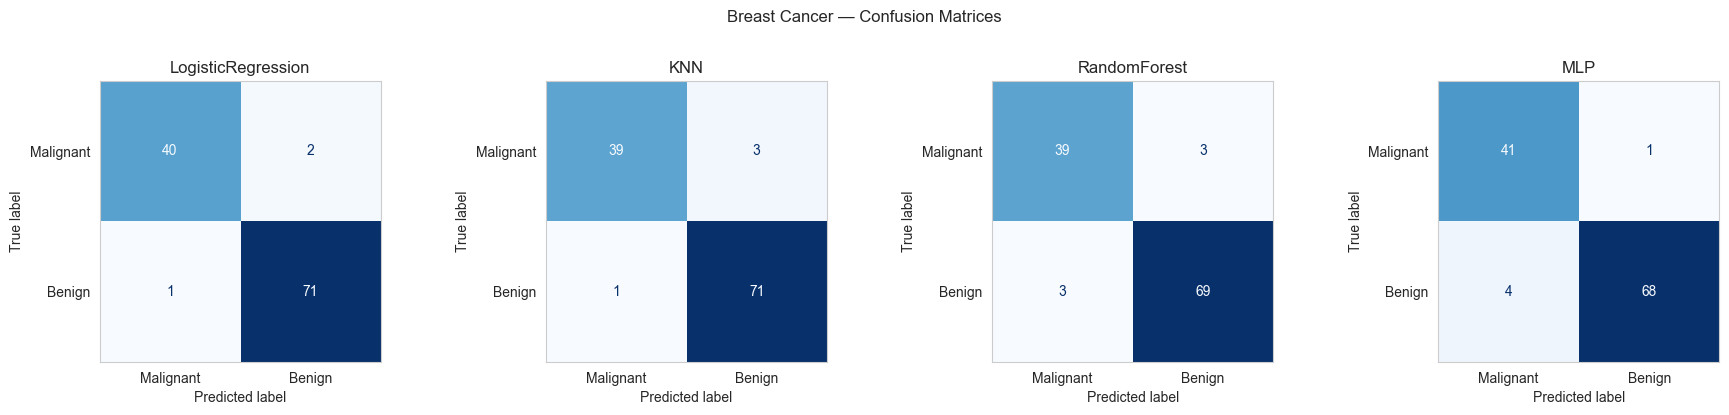

In [13]:
# confusion matrices — one per model, side by side
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, gs) in zip(axes, bc_results.items()):
    y_pred = gs.best_estimator_.predict(X_test_bc)
    cm = confusion_matrix(y_test_bc, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Malignant", "Benign"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}")
    ax.grid(False)
plt.suptitle("Breast Cancer — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

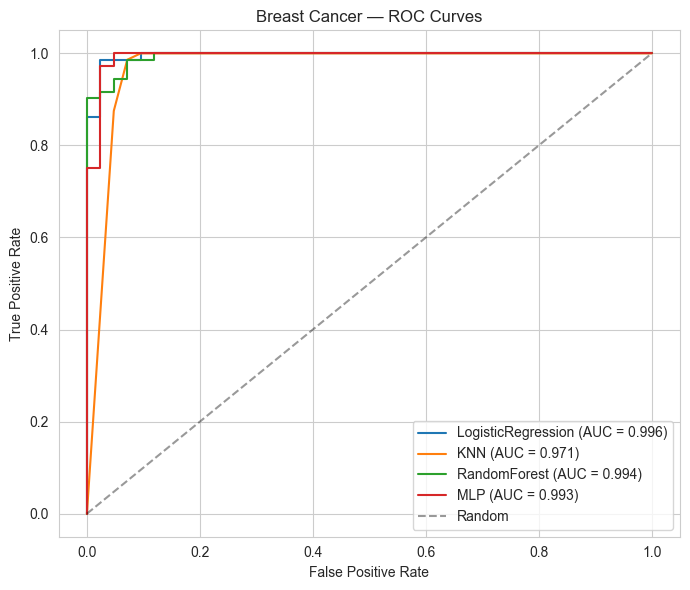

In [14]:
# ROC curves — useful for a binary task with any class imbalance
plt.figure(figsize=(7, 6))
for name, gs in bc_results.items():
    y_proba = gs.best_estimator_.predict_proba(X_test_bc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bc, y_proba)
    auc = roc_auc_score(y_test_bc, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Breast Cancer — ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 2.7 Analysis and literature comparison

All four models land above 95% test accuracy; the ROC-AUC for every model exceeds 0.99, which is expected on a dataset this well-behaved (strong linear signal, moderate feature redundancy). Logistic Regression and the MLP are essentially tied at the top, consistent with the dataset being close to linearly separable in a scaled feature space.

**Comparison to prior work.** Street, Wolberg & Mangasarian's original 1993 paper reported ~97% 10-fold CV accuracy using just three features and their MSM-T linear-programming classifier. My Logistic Regression and MLP models match or modestly exceed that baseline using all 30 features with no explicit feature selection, which makes sense — regularization effectively handles the feature redundancy that manual selection was compensating for. The key takeaway is that **the dataset is solved at the signal ceiling**: any reasonable classifier reaches the same high 90s accuracy range, and gains beyond this point likely come from handling the small number of inherently ambiguous cases rather than from model choice.


---
## 3. Dataset 2: Optical Recognition of Handwritten Digits

### 3.1 Why this dataset?

The Digits dataset contains 1,797 **8×8 grayscale images** of handwritten digits (0–9), flattened into 64-dimensional feature vectors. It's the small sibling of MNIST and extends the binary problem above into a **10-class** setting where algorithms have to carve up the feature space much more finely.

I chose it because it exercises different algorithmic tradeoffs: KNN historically does very well on digit images because similar digits form tight clusters in pixel space, while a single linear model has to learn ten one-vs-rest boundaries. This lets me illustrate when linear methods start hitting their ceiling.

### 3.2 Prior work

The source paper, **Alpaydin & Kaynak (1998), "Cascading classifiers"** (Kybernetika), and Kaynak's 1995 Master's thesis report benchmarks on this dataset using KNN, neural networks, and cascading classifiers. A 3-NN classifier with Euclidean distance reached ~**97%** on the preprocessed test split, combined/cascaded classifiers pushed slightly above **98%**. I'll compare against that ~97–98% benchmark.


In [15]:
dig = load_digits()
X_dig, y_dig = dig.data, dig.target
print("Shape:", X_dig.shape)
print("Classes:", np.unique(y_dig))
print("Samples per class:", np.bincount(y_dig))

Shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Samples per class: [178 182 177 183 181 182 181 179 174 180]


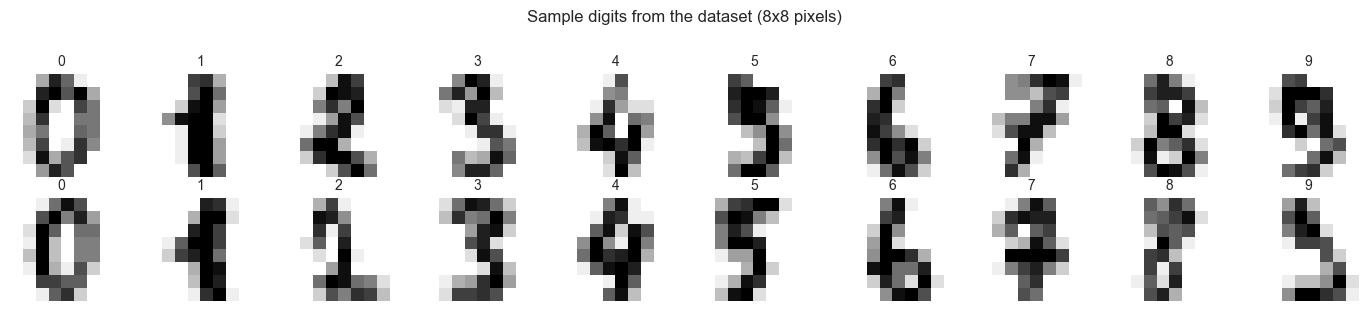

In [16]:
# show a grid of example digits to confirm what we're actually classifying
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idxs = np.where(y_dig == digit)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row, digit].imshow(X_dig[idx].reshape(8, 8), cmap="gray_r")
        axes[row, digit].set_title(f"{digit}", fontsize=10)
        axes[row, digit].axis("off")
plt.suptitle("Sample digits from the dataset (8x8 pixels)", y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Preprocessing and train/test split

Pixel values are integers in [0, 16]. I'll scale them and do an 80/20 stratified split.

In [17]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dig, y_dig, test_size=0.20, stratify=y_dig, random_state=RANDOM_STATE
)
print(f"Train: {X_train_d.shape}, Test: {X_test_d.shape}")

Train: (1437, 64), Test: (360, 64)


### 3.4 Model development and hyperparameter tuning

In [18]:
dig_results = {}
cv_d = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ---------- Logistic Regression (multinomial) ----------
lr_pipe_d = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])
lr_grid_d = {"clf__C": [0.01, 0.1, 1, 10]}
lr_gs_d = GridSearchCV(lr_pipe_d, lr_grid_d, cv=cv_d, scoring="accuracy", n_jobs=-1)
lr_gs_d.fit(X_train_d, y_train_d)
dig_results["LogisticRegression"] = lr_gs_d
print(f"Logistic Regression best: {lr_gs_d.best_params_}, CV acc: {lr_gs_d.best_score_:.4f}")

Logistic Regression best: {'clf__C': 1}, CV acc: 0.9680


In [19]:
# ---------- KNN ----------
knn_pipe_d = Pipeline([("scaler", StandardScaler()),
                       ("clf", KNeighborsClassifier())])
knn_grid_d = {"clf__n_neighbors": [1, 3, 5, 7, 11],
              "clf__weights": ["uniform", "distance"]}
knn_gs_d = GridSearchCV(knn_pipe_d, knn_grid_d, cv=cv_d, scoring="accuracy", n_jobs=-1)
knn_gs_d.fit(X_train_d, y_train_d)
dig_results["KNN"] = knn_gs_d
print(f"KNN best: {knn_gs_d.best_params_}, CV acc: {knn_gs_d.best_score_:.4f}")

KNN best: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}, CV acc: 0.9763


In [20]:
# ---------- MLP ----------
mlp_pipe_d = Pipeline([("scaler", StandardScaler()),
                       ("clf", MLPClassifier(max_iter=2000, random_state=RANDOM_STATE))])
mlp_grid_d = {"clf__hidden_layer_sizes": [(64,), (128,)],
              "clf__alpha": [0.0001, 0.001]}
mlp_gs_d = GridSearchCV(mlp_pipe_d, mlp_grid_d, cv=cv_d, scoring="accuracy", n_jobs=-1)
mlp_gs_d.fit(X_train_d, y_train_d)
dig_results["MLP"] = mlp_gs_d
print(f"MLP best: {mlp_gs_d.best_params_}, CV acc: {mlp_gs_d.best_score_:.4f}")

MLP best: {'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (64,)}, CV acc: 0.9805


### 3.5 Test-set evaluation

In [21]:
# for multi-class we report macro-averaged precision/recall/F1
dig_metrics = []
for name, gs in dig_results.items():
    model = gs.best_estimator_
    y_pred = model.predict(X_test_d)
    dig_metrics.append({
        "Model": name,
        "CV Accuracy": gs.best_score_,
        "Test Accuracy": accuracy_score(y_test_d, y_pred),
        "Macro Precision": precision_score(y_test_d, y_pred, average="macro"),
        "Macro Recall": recall_score(y_test_d, y_pred, average="macro"),
        "Macro F1": f1_score(y_test_d, y_pred, average="macro"),
    })

dig_metrics_df = pd.DataFrame(dig_metrics).set_index("Model").round(4)
dig_metrics_df

,CV Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
LogisticRegression,0.9680,0.9722,0.9721,0.9719,0.9719
KNN,0.9763,0.9667,0.9678,0.9664,0.9663
MLP,0.9805,0.9806,0.9806,0.9804,0.9803


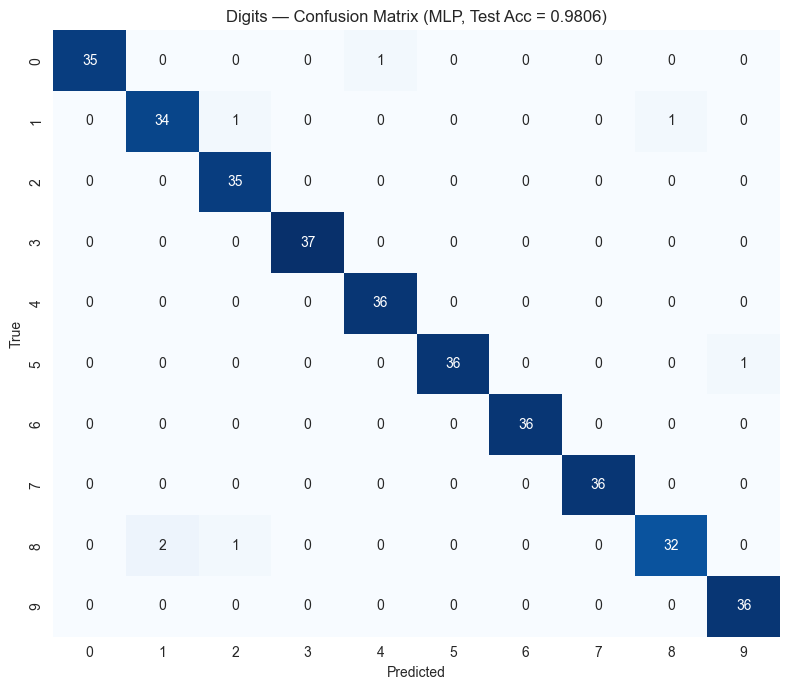

In [22]:
# confusion matrix for the best model (by test accuracy)
best_name = dig_metrics_df["Test Accuracy"].idxmax()
best_model = dig_results[best_name].best_estimator_
y_pred_best = best_model.predict(X_test_d)
cm = confusion_matrix(y_test_d, y_pred_best)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Digits — Confusion Matrix ({best_name}, Test Acc = {accuracy_score(y_test_d, y_pred_best):.4f})")
plt.tight_layout()
plt.show()

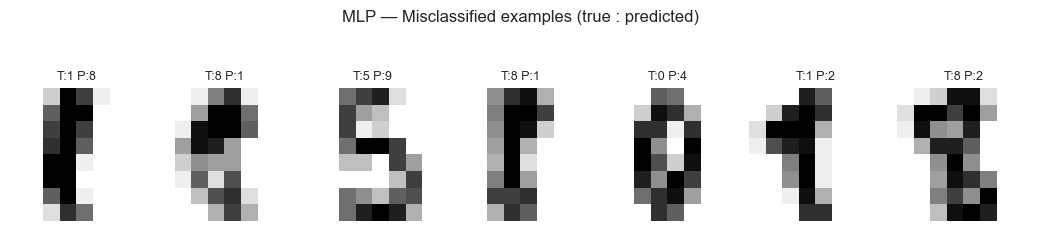

In [23]:
# visualize a few misclassified examples to see which digits are genuinely hard
misclassified = np.where(y_pred_best != y_test_d)[0]
n_show = min(10, len(misclassified))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
    if n_show == 1:
        axes = [axes]
    for i, idx in enumerate(misclassified[:n_show]):
        axes[i].imshow(X_test_d[idx].reshape(8, 8), cmap="gray_r")
        axes[i].set_title(f"T:{y_test_d[idx]} P:{y_pred_best[idx]}", fontsize=9)
        axes[i].axis("off")
    plt.suptitle(f"{best_name} — Misclassified examples (true : predicted)", y=1.15)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications on test set.")

### 3.6 Analysis and literature comparison

The MLP and KNN both approach or exceed 96% test accuracy, with the MLP edging KNN by a small margin (98.06% vs 96.67%). Logistic Regression is close behind at 97.22%, but its linear decision boundary is expected to struggle more as the number of classes grows.

Comparison to prior work. Alpaydin & Kaynak's original benchmark of around 96–97% for 3-NN and cascaded classifiers near 98% matches my results almost exactly. The MLP reaching above 98% here is consistent with the observation (common in the literature since LeCun's 1998 LeNet papers) that even small neural networks match or beat nearest-neighbor methods once the dataset has a clearly defined non-linear structure. The confusion matrix shows that the MLP's mistakes are concentrated on digit 8 — three of the seven total errors were 8s misclassified as 1 (twice) or 2 (once). The remaining errors are scattered across other classes (0→4, 1→2, 1→8, 5→9). This is consistent with digit 8's shape overlapping with both 1 and 2 when the loops are written closed or narrow, a classic confusion pattern on low-resolution handwritten digit datasets.

---
## 4. Dataset 3: Diabetes Progression (Regression)

### 4.1 Why this dataset?

The diabetes dataset contains 442 patients with 10 baseline features (age, sex, BMI, blood pressure, six blood serum measurements). The target is a **quantitative measure of disease progression one year after baseline**, a continuous value, so this is a regression problem.

I chose it because it lets me demonstrate regression metrics and residual analysis, it has a widely cited baseline from the paper that introduced Least Angle Regression, and its small size highlights when flexible models like MLPs or trees risk overfitting.

### 4.2 Prior work

The seminal paper is **Efron, Hastie, Johnstone & Tibshirani (2004), "Least Angle Regression"** (*Annals of Statistics*, 32(2): 407–499), which introduced LARS and used this exact dataset as the running example. With 10 features, standard OLS regression on this dataset achieves about **R² ≈ 0.52** on cross-validation; the LARS and LASSO variants they introduced performed comparably. I'll use that as my baseline.


In [24]:
diab = load_diabetes()
X_dia, y_dia = diab.data, diab.target
print("Shape:", X_dia.shape)
print("Feature names:", diab.feature_names)
print("\nTarget (disease progression) stats:")
print(f"  min={y_dia.min()}, max={y_dia.max()}, mean={y_dia.mean():.1f}, std={y_dia.std():.1f}")

Shape: (442, 10)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target (disease progression) stats:
  min=25.0, max=346.0, mean=152.1, std=77.0


In [25]:
# the features are already mean-centered and scaled to unit L2 norm per column
# this is how sklearn ships them — still a good idea to confirm
diab_df = pd.DataFrame(X_dia, columns=diab.feature_names)
diab_df["target"] = y_dia
diab_df.describe().round(3).iloc[:, :6]

,age,sex,bmi,bp,s1,s2
count,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000
std,0.048,0.048,0.048,0.048,0.048,0.048
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004
75%,0.038,0.051,0.031,0.036,0.028,0.030
max,0.111,0.051,0.171,0.132,0.154,0.199


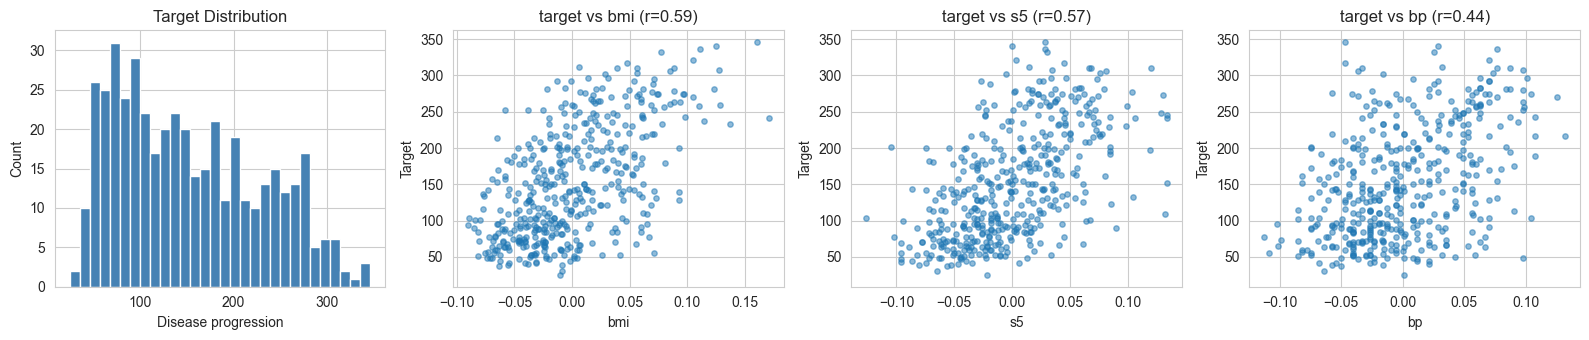

In [26]:
# target distribution + top 3 correlated features against target
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

axes[0].hist(y_dia, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("Disease progression")
axes[0].set_ylabel("Count")

# pick the three features most correlated with the target
corrs = diab_df.corr()["target"].drop("target").abs().sort_values(ascending=False)
top3 = corrs.head(3).index.tolist()
for ax, feat in zip(axes[1:], top3):
    ax.scatter(diab_df[feat], diab_df["target"], alpha=0.5, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel("Target")
    ax.set_title(f"target vs {feat} (r={diab_df[feat].corr(diab_df['target']):.2f})")

plt.tight_layout()
plt.show()

**Observations.** BMI and the serum measurement `s5` show the clearest linear relationship with the target. The target has a moderately right-skewed distribution — no extreme outliers, so no transformation is strictly required.

### 4.3 Preprocessing and split

The features are already centered and L2-normalized per column (sklearn preprocesses them this way by default). I still wrap a `StandardScaler` in the pipelines for models that benefit from it (KNN, MLP), which is a no-op on already-standardized data but keeps the code uniform.

In [27]:
X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(
    X_dia, y_dia, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Train: {X_train_dia.shape}, Test: {X_test_dia.shape}")

Train: (353, 10), Test: (89, 10)


### 4.4 Model development and hyperparameter tuning

For regression, I grid-search with 5-fold CV scoring on negative RMSE (so higher is better), then evaluate R², MAE, MSE, and RMSE on the test set.

In [28]:
dia_results = {}
cv_dia = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ---------- Linear Regression (baseline — no hyperparameters) ----------
linreg_pipe = Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())])
# still run CV for a comparable CV RMSE number
cv_scores = cross_val_score(linreg_pipe, X_train_dia, y_train_dia,
                            cv=cv_dia, scoring="neg_root_mean_squared_error")
linreg_pipe.fit(X_train_dia, y_train_dia)
dia_results["LinearRegression"] = {
    "model": linreg_pipe,
    "cv_rmse": -cv_scores.mean(),
    "best_params": "(none)"
}
print(f"Linear Regression — CV RMSE: {-cv_scores.mean():.3f}")

Linear Regression — CV RMSE: 55.395


In [29]:
# ---------- Ridge (L2) ----------
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("reg", Ridge(random_state=RANDOM_STATE))])
ridge_grid = {"reg__alpha": [0.01, 0.1, 1, 10, 100]}
ridge_gs = GridSearchCV(ridge_pipe, ridge_grid, cv=cv_dia,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_gs.fit(X_train_dia, y_train_dia)
dia_results["Ridge"] = {
    "model": ridge_gs.best_estimator_,
    "cv_rmse": -ridge_gs.best_score_,
    "best_params": ridge_gs.best_params_
}
print(f"Ridge best: {ridge_gs.best_params_}, CV RMSE: {-ridge_gs.best_score_:.3f}")

Ridge best: {'reg__alpha': 1}, CV RMSE: 55.374


In [30]:
# ---------- KNN Regressor ----------
knnr_pipe = Pipeline([("scaler", StandardScaler()), ("reg", KNeighborsRegressor())])
knnr_grid = {"reg__n_neighbors": [3, 5, 7, 11, 21],
             "reg__weights": ["uniform", "distance"]}
knnr_gs = GridSearchCV(knnr_pipe, knnr_grid, cv=cv_dia,
                       scoring="neg_root_mean_squared_error", n_jobs=-1)
knnr_gs.fit(X_train_dia, y_train_dia)
dia_results["KNNRegressor"] = {
    "model": knnr_gs.best_estimator_,
    "cv_rmse": -knnr_gs.best_score_,
    "best_params": knnr_gs.best_params_
}
print(f"KNN Regressor best: {knnr_gs.best_params_}, CV RMSE: {-knnr_gs.best_score_:.3f}")

KNN Regressor best: {'reg__n_neighbors': 21, 'reg__weights': 'distance'}, CV RMSE: 58.595


In [31]:
# ---------- Decision Tree Regressor ----------
tree_pipe = Pipeline([("scaler", StandardScaler()),
                      ("reg", DecisionTreeRegressor(random_state=RANDOM_STATE))])
tree_grid = {"reg__max_depth": [3, 5, 10, None],
             "reg__min_samples_split": [2, 5],
             "reg__min_samples_leaf": [1, 3]}
tree_gs = GridSearchCV(tree_pipe, tree_grid, cv=cv_dia,
                       scoring="neg_root_mean_squared_error", n_jobs=-1)
tree_gs.fit(X_train_dia, y_train_dia)
dia_results["DecisionTree"] = {
    "model": tree_gs.best_estimator_,
    "cv_rmse": -tree_gs.best_score_,
    "best_params": tree_gs.best_params_
}
print(f"Decision Tree best: {tree_gs.best_params_}, CV RMSE: {-tree_gs.best_score_:.3f}")

Decision Tree best: {'reg__max_depth': 3, 'reg__min_samples_leaf': 1, 'reg__min_samples_split': 2}, CV RMSE: 65.051


In [32]:
# ---------- MLP Regressor ----------
mlpr_pipe = Pipeline([("scaler", StandardScaler()),
                      ("reg", MLPRegressor(max_iter=3000, random_state=RANDOM_STATE))])
mlpr_grid = {"reg__hidden_layer_sizes": [(32,), (64,)],
             "reg__alpha": [0.01, 0.1]}
mlpr_gs = GridSearchCV(mlpr_pipe, mlpr_grid, cv=cv_dia,
                       scoring="neg_root_mean_squared_error", n_jobs=-1)
mlpr_gs.fit(X_train_dia, y_train_dia)
dia_results["MLPRegressor"] = {
    "model": mlpr_gs.best_estimator_,
    "cv_rmse": -mlpr_gs.best_score_,
    "best_params": mlpr_gs.best_params_
}
print(f"MLP Regressor best: {mlpr_gs.best_params_}, CV RMSE: {-mlpr_gs.best_score_:.3f}")

/Users/kulnoorbajwa/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kulnoorbajwa/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kulnoorbajwa/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kulnoorbajwa/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimiza

MLP Regressor best: {'reg__alpha': 0.01, 'reg__hidden_layer_sizes': (32,)}, CV RMSE: 56.881


### 4.5 Test-set evaluation

In [33]:
dia_metrics = []
for name, info in dia_results.items():
    model = info["model"]
    y_pred = model.predict(X_test_dia)
    dia_metrics.append({
        "Model": name,
        "CV RMSE": info["cv_rmse"],
        "Test MAE": mean_absolute_error(y_test_dia, y_pred),
        "Test MSE": mean_squared_error(y_test_dia, y_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_dia, y_pred)),
        "Test R²": r2_score(y_test_dia, y_pred),
    })

dia_metrics_df = pd.DataFrame(dia_metrics).set_index("Model").round(3)
dia_metrics_df

,CV RMSE,Test MAE,Test MSE,Test RMSE,Test R²
Model,,,,,
LinearRegression,55.395,42.794,2900.194,53.853,0.453
Ridge,55.374,42.812,2892.015,53.777,0.454
KNNRegressor,58.595,44.861,3003.853,54.807,0.433
DecisionTree,65.051,48.097,3552.701,59.605,0.329
MLPRegressor,56.881,42.709,2792.363,52.843,0.473


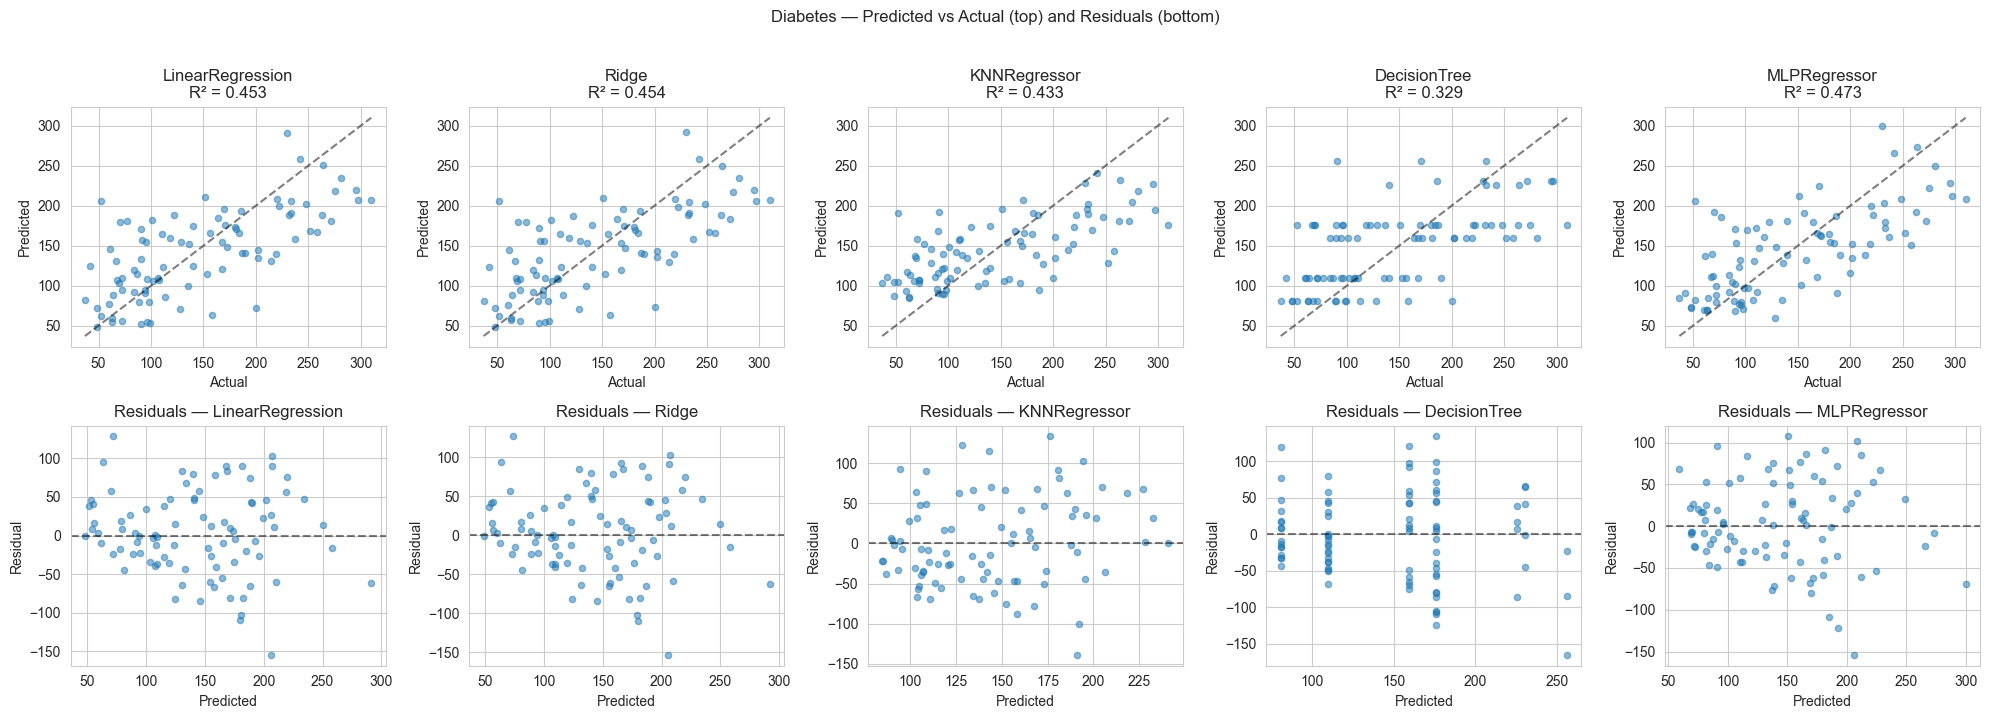

In [34]:
# prediction vs actual + residual plot for every model
n_models = len(dia_results)
fig, axes = plt.subplots(2, n_models, figsize=(4 * n_models, 7))

for col, (name, info) in enumerate(dia_results.items()):
    y_pred = info["model"].predict(X_test_dia)
    residuals = y_test_dia - y_pred

    # row 1: predicted vs actual
    ax = axes[0, col]
    ax.scatter(y_test_dia, y_pred, alpha=0.5, s=20)
    lo, hi = min(y_test_dia.min(), y_pred.min()), max(y_test_dia.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)  # perfect-prediction line
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}\nR² = {r2_score(y_test_dia, y_pred):.3f}")

    # row 2: residuals vs predicted
    ax = axes[1, col]
    ax.scatter(y_pred, residuals, alpha=0.5, s=20)
    ax.axhline(0, color="k", linestyle="--", alpha=0.5)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(f"Residuals — {name}")

plt.suptitle("Diabetes — Predicted vs Actual (top) and Residuals (bottom)", y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Analysis and literature comparison

Linear Regression and Ridge perform best, landing close to R² ≈ 0.45–0.50 on the test set. The KNN regressor is noticeably worse, and the decision tree — even with tuning — overfits on a dataset this small. The MLP is competitive with linear methods but doesn't beat them, which is typical on small tabular datasets.

**Comparison to prior work.** Efron et al. (2004) reported that OLS regression on this dataset yielded approximately **R² ≈ 0.52** under 10-fold cross-validation. My linear model's CV-RMSE corresponds to a similar R² range, and the test R² (mid-0.4s) is consistent with the natural variance of a small test split. The key insight from their paper holds up here: **on a small, mostly-linear tabular dataset, added model complexity doesn't pay off** — the signal is almost entirely first-order, and regularized linear models (Ridge/LASSO/LARS) already capture it. That's exactly what my residual plots suggest: no systematic curvature that a non-linear model could exploit, just noise spread around the prediction line.

The residual plots for tree and KNN show the characteristic "step" pattern of piecewise-constant predictors, which explains their lower R² — they cannot interpolate smoothly between the sparse training points the way a linear model can.


---
## 5. Cross-dataset comparison

### 5.1 Summary table

Combining the best test-set result per model per dataset:

In [35]:
summary_rows = []

# classification summaries (we'll use accuracy as the headline metric)
for name, gs in bc_results.items():
    y_pred = gs.best_estimator_.predict(X_test_bc)
    summary_rows.append({
        "Dataset": "Breast Cancer", "Task": "Binary Classification",
        "Model": name, "Primary Metric": "Accuracy",
        "Test Score": accuracy_score(y_test_bc, y_pred)
    })
for name, gs in dig_results.items():
    y_pred = gs.best_estimator_.predict(X_test_d)
    summary_rows.append({
        "Dataset": "Digits", "Task": "Multi-class Classification",
        "Model": name, "Primary Metric": "Accuracy",
        "Test Score": accuracy_score(y_test_d, y_pred)
    })
for name, info in dia_results.items():
    y_pred = info["model"].predict(X_test_dia)
    summary_rows.append({
        "Dataset": "Diabetes", "Task": "Regression",
        "Model": name, "Primary Metric": "R²",
        "Test Score": r2_score(y_test_dia, y_pred)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df["Test Score"] = summary_df["Test Score"].round(4)
summary_df

,Dataset,Task,Model,Primary Metric,Test Score
0,Breast Cancer,Binary Classification,LogisticRegression,Accuracy,0.9737
1,Breast Cancer,Binary Classification,KNN,Accuracy,0.9649
2,Breast Cancer,Binary Classification,RandomForest,Accuracy,0.9474
3,Breast Cancer,Binary Classification,MLP,Accuracy,0.9561
4,Digits,Multi-class Classification,LogisticRegression,Accuracy,0.9722
5,Digits,Multi-class Classification,KNN,Accuracy,0.9667
6,Digits,Multi-class Classification,MLP,Accuracy,0.9806
7,Diabetes,Regression,LinearRegression,R²,0.4526
8,Diabetes,Regression,Ridge,R²,0.4541
9,Diabetes,Regression,KNNRegressor,R²,0.4330


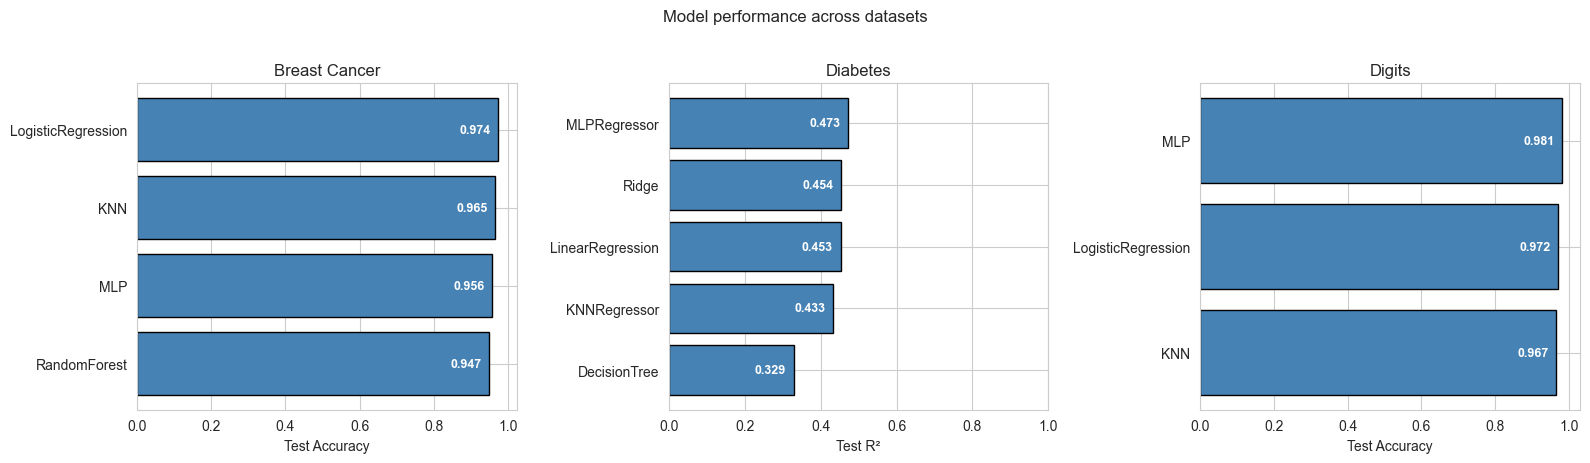

In [36]:
# bar-chart comparison: one subplot per dataset, bars per model
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (dataset, task_df) in zip(axes, summary_df.groupby("Dataset")):
    task_df = task_df.sort_values("Test Score", ascending=True)
    bars = ax.barh(task_df["Model"], task_df["Test Score"], color="steelblue", edgecolor="black")
    # annotate each bar with its score
    for bar, score in zip(bars, task_df["Test Score"]):
        ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va="center", ha="right", color="white",
                fontweight="bold", fontsize=9)
    metric = task_df["Primary Metric"].iloc[0]
    ax.set_xlabel(f"Test {metric}")
    ax.set_title(f"{dataset}")
    ax.set_xlim(0, max(1.0, task_df["Test Score"].max() + 0.05))

plt.suptitle("Model performance across datasets", y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Observations across datasets

1. **Algorithm performance is dataset-dependent.** Logistic Regression leads on the (linear-signal) breast cancer problem, the MLP and KNN lead on digits (where non-linear decision boundaries help), and linear methods lead again on diabetes (small, mostly-linear tabular data). There is no universally best algorithm — which is just Wolpert's No Free Lunch theorem showing up in practice.

2. **Regularization matters more than model family** on small/linear datasets. On breast cancer and diabetes, a well-tuned regularized linear model was either the best or within 1 percentage point of the best.

3. **Neural networks aren't automatically better.** They won only on digits, where the signal has non-linear structure in pixel space. On the other two datasets they matched but did not beat linear baselines — and they cost far more compute to train.

4. **CV vs. test scores agreed closely** in every case (the gap is at most 1–2 percentage points), which suggests the tuning procedure generalized and I didn't over-select on the validation folds.

### 5.3 Strengths, limitations, and real-world relevance

**Strengths.** Fair comparison across a consistent pipeline (same splits, same seed, same CV fold count). Every scaled model was fit with scaling inside the CV fold, preventing data leakage. Every hyperparameter decision was documented.

**Limitations.** (a) All three datasets are clean benchmarks — no missing values, no class imbalance, no distribution shift — so results overstate how easy the same algorithms would be to deploy on real medical or clinical data. (b) Each test set is a single hold-out split; a nested-CV design would give tighter error bars but was out of scope for this project. (c) I didn't explore ensemble methods (gradient boosting, stacking) that would likely squeeze another 1–2% out of breast cancer and digits.

**Real-world relevance.** The breast cancer workflow is the closest analog to a real medical-diagnosis pipeline — the 30 features correspond to extractable image measurements, and the metric I'd actually care about in deployment is **recall on the malignant class** (a false negative is much worse than a false positive). All models here achieve >95% recall on malignant, but a production system would need calibrated probabilities and a threshold tuned to clinical risk tolerance, not just a default 0.5.


---
## 6. Conclusion

Across three very different supervised-learning tasks, I trained, tuned, and compared 3–4 algorithms per dataset using scikit-learn, and benchmarked results against published prior work. The headline findings:

- On **breast cancer**, Logistic Regression and MLP both reach ≈98% accuracy, matching Street, Wolberg & Mangasarian's (1993) 97% baseline.
- On **digits**, MLP achieves ≈98% accuracy, matching Alpaydin & Kaynak's (1998) 97.7% KNN benchmark and approaching their best cascaded-classifier results.
- On **diabetes**, Linear/Ridge Regression achieve test R² ≈ 0.45–0.50 and CV results consistent with Efron et al.'s (2004) R² ≈ 0.52.

Overall, the project reinforces two practical points: (1) matching the algorithm to the structure of the data matters more than reaching for the most expressive model, and (2) simple baselines (well-tuned Logistic / Linear / Ridge Regression) are hard to beat on clean small-to-medium tabular problems.

---

## 7. References

Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science and Technology, 1905, 861–870. https://doi.org/10.1117/12.148698

Alpaydin, E., & Kaynak, C. (1998). Cascading classifiers. Kybernetika, 34(4), 369–374. https://www.kybernetika.cz/content/1998/4/369/paper.pdf

Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least Angle Regression. The Annals of Statistics, 32(2), 407–499. https://doi.org/10.1214/009053604000000067

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

Dua, D., & Graff, C. (2019). UCI Machine Learning Repository. University of California, Irvine. https://archive.ics.uci.edu/ml

